## 02 — Phase 1: Train on Synthetic Data

### 0. Setup

In [4]:
# Core imports
import os
from pathlib import Path

# ── Project root ──────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
print(f"Project root: {PROJECT_ROOT}")

# ── Paths (all under data/) ────────────────────────────────────────────────────
DATA_DIR       = PROJECT_ROOT / 'data'
DATASET_DIR    = PROJECT_ROOT / 'yolo_dataset'
TRAINING_DIR   = DATA_DIR / 'noodles_training'

# ── Shared constants ──────────────────────────────────────────────────────────
PIECE_LABELS     = list('ABCDEFGHIJK')               # piece classes 0-10 (unchanged)
ALL_CLASS_NAMES  = PIECE_LABELS + ['board', 'hinge'] # class 11 (board) + 12 (hinge)
NUM_CLASSES      = len(ALL_CLASS_NAMES)              # 13


yaml_path = Path('/home/salumi/projects/project/yolo_dataset/dataset.yaml')
assert yaml_path.exists(), f"Synthetic dataset YAML not found at {yaml_path}. Run notebook 01 first!"
print(f"\n✅ Dataset YAML: {yaml_path}")

Project root: /home/salumi/projects/project

✅ Dataset YAML: /home/salumi/projects/project/yolo_dataset/dataset.yaml


### 1. Load Model & Train Phase 1

In [5]:
from ultralytics import YOLO

# ── Model selection ───────────────────────────────────────────────────────────
MODEL_SIZE = 'yolo26n-seg.pt'
model = YOLO(MODEL_SIZE)

print(f"✅ Loaded {MODEL_SIZE} model")
print(f"   Parameters: {sum(p.numel() for p in model.model.parameters()):,}")

✅ Loaded yolo26n-seg.pt model
   Parameters: 3,126,280


In [6]:
# Phase 1: Train on synthetic data
results_phase1 = model.train(
    data=str(Path('/home/salumi/projects/project/yolo_dataset/dataset.yaml')),
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=20,
    save=True,
    save_period=25,
    project=str(TRAINING_DIR),
    name='phase1_synthetic',
    exist_ok=True,
    # Augmentation settings
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=15.0,
    translate=0.1,
    scale=0.4,
    fliplr=0.5,
    flipud=0.1,
    mosaic=0.8,
    mixup=0.1,
    copy_paste=0.2,
)

print("\n✅ Phase 1 training complete (synthetic data)!")

New https://pypi.org/project/ultralytics/8.4.32 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.11.0rc1 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/salumi/projects/project/yolo_dataset/dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26n-seg.pt, momentum=0.937, 

### 2. Validate Phase 1

In [7]:
# Load trained model weights for validation (no retraining)
from ultralytics import YOLO

# Path to the best weights from phase 1 training
PHASE1_WEIGHTS = TRAINING_DIR / 'phase1_synthetic' / 'weights' / 'best.pt'
assert PHASE1_WEIGHTS.exists(), f"Trained weights not found at {PHASE1_WEIGHTS}"
model = YOLO(str(PHASE1_WEIGHTS))
print(f"Loaded trained model from: {PHASE1_WEIGHTS}")

# Phase 1 validation on synthetic val set
metrics_p1 = model.val(
    data=str(yaml_path),
    imgsz=640,
    batch=16,
    device=0,
)

print("\n=== Phase 1 Validation Metrics (Synthetic) ===")
print(f"  Box  mAP@0.5:     {metrics_p1.box.map50:.4f}")
print(f"  Box  mAP@0.5:0.95: {metrics_p1.box.map:.4f}")
print(f"  Mask mAP@0.5:     {metrics_p1.seg.map50:.4f}")
print(f"  Mask mAP@0.5:0.95: {metrics_p1.seg.map:.4f}")

print("\n=== Per-Class mAP@0.5 (Mask) ===")
if hasattr(metrics_p1.seg, 'ap50') and metrics_p1.seg.ap50 is not None:
    for i, ap in enumerate(metrics_p1.seg.ap50):
        name = model.names[i]
        print(f"  {name}: {ap:.4f}")

Loaded trained model from: /home/salumi/projects/project/data/noodles_training/phase1_synthetic/weights/best.pt
Ultralytics 8.4.21 🚀 Python-3.11.0rc1 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO26n-seg summary (fused): 139 layers, 2,691,419 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6397.0±1025.5 MB/s, size: 1256.1 KB)
val: Scanning /home/salumi/projects/project/yolo_dataset/labels/val.cache... 345 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 345/345 111.3Mit/s 0.0s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 3.3it/s 6.7s0.2s
                   all        345       1526      0.988      0.982      0.994      0.988      0.988      0.982      0.994      0.972
              A_Yellow        132        132      0.968      0.992      0.994      0.994      0.968      0.992      0.994      0.988
             B_SkyBlue        125        125      0.991      0.992      0.995      0.995      0.991      0.992      0.995      0.987
            C_DarkBlue        120        120      0.983      0.992      0.994      0.992      0.983      0.992      0.994       0.92
               D_Green        131        131      0.992      0.997      0.995      0.995      0.992      0.997      0.995      0.943
                 E_Red        133        133      0.992      0.976      0.995      0.995      0.992      0.976      0.995      0.957
                F_Teal     

In [8]:
# Show model summary (architecture and parameters)
model.info()

# Export to ONNX for graphical visualization in Netron:
onnx_path = model.export(format="onnx")
print(f"\nONNX model exported to: {onnx_path}")
print("To view the model graphically, open the .onnx file in https://netron.app or the Netron desktop app.")

YOLO26n-seg summary (fused): 139 layers, 2,691,419 parameters, 0 gradients, 9.0 GFLOPs
Ultralytics 8.4.21 🚀 Python-3.11.0rc1 torch-2.10.0+cu128 CPU (11th Gen Intel Core i7-11700K @ 3.60GHz)

PyTorch: starting from '/home/salumi/projects/project/data/noodles_training/phase1_synthetic/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 300, 38), (1, 32, 160, 160)) (6.3 MB)

ONNX: starting export with onnx 1.20.1 opset 22...


/home/salumi/projects/project/.venv/lib/python3.11/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(
/home/salumi/projects/project/.venv/lib/python3.11/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 22 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 3.7s, saved as '/home/salumi/projects/project/data/noodles_training/phase1_synthetic/weights/best.onnx' (10.6 MB)

Export complete (4.0s)
Results saved to /home/salumi/projects/project/data/noodles_training/phase1_synthetic/weights
Predict:         yolo predict task=segment model=/home/salumi/projects/project/data/noodles_training/phase1_synthetic/weights/best.onnx imgsz=640 
Validate:        yolo val task=segment model=/home/salumi/projects/project/data/noodles_training/phase1_synthetic/weights/best.onnx imgsz=640 data=/home/salumi/projects/project/yolo_dataset/dataset.yaml  
Visualize:       https://netron.app

ONNX model exported to: /home/salumi/projects/project/data/noodles_training/phase1_synthetic/weights/best.onnx
To view the model graphically, open the .onnx file in https://netron.app or the Netron desktop app.


In [9]:
# Predict and visualize results on a sample image
from PIL import Image
import matplotlib.pyplot as plt

# Path to a sample image (update this path as needed)
sample_image_path = DATASET_DIR / 'images' / 'train' / sorted(os.listdir(DATASET_DIR / 'images' / 'train'))[0]

# Run prediction
results = model.predict(source=str(sample_image_path), save=False, show=False)

# Visualize prediction
result_img = results[0].plot()
plt.figure(figsize=(8, 8))
plt.imshow(result_img)
plt.axis('off')
plt.title('YOLO Prediction Result')
plt.show()

image 1/1 /home/salumi/projects/project/yolo_dataset/images/train/000000.png: 640x640 1 C_DarkBlue, 1 H_Purple, 1 I_Orange, 1 K_YellowGreen, 18.6ms
Speed: 4.6ms preprocess, 18.6ms inference, 42.2ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 800x800 with 1 Axes>

In [10]:
# Robust inline display: original, overlay, and per-instance crops
from IPython.display import display
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# choose a sample image
sample_dir = DATASET_DIR / 'images' / 'train'
sample_files = sorted([f for f in os.listdir(sample_dir) if not f.startswith('.')])
assert len(sample_files) > 0, f"No images found in {sample_dir}"
sample_image_path = sample_dir / sample_files[0]
print(f"Using image: {sample_image_path}")

# run prediction (no saving) and get first result
results = model.predict(source=str(sample_image_path), save=False, show=False)
res = results[0]

# get plotted overlay (ndarray or PIL.Image)
try:
    overlay = res.plot()
except Exception as e:
    print('res.plot() failed:', e)
    overlay = None

# load original image as PIL
orig = Image.open(sample_image_path).convert('RGB')

# display original and overlay side-by-side
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(orig)
plt.title('Original')
plt.axis('off')

if overlay is not None:
    if isinstance(overlay, np.ndarray):
        overlay_img = Image.fromarray(overlay)
    else:
        overlay_img = overlay
    plt.subplot(1,2,2)
    plt.imshow(overlay_img)
    plt.title('YOLO Overlay')
    plt.axis('off')
else:
    plt.subplot(1,2,2)
    plt.text(0.5,0.5,'Overlay unavailable',ha='center',va='center')
    plt.axis('off')

plt.show()

# show per-instance crops (boxes and class names) if available
try:
    boxes = getattr(res, 'boxes', None)
    if boxes is not None and len(boxes) > 0:
        # boxes.xyxy may be torch tensor or ndarray
        xyxy = None
        try:
            xyxy = boxes.xyxy.numpy()  # if torch->numpy
        except Exception:
            try:
                xyxy = np.array(boxes.xyxy)
            except Exception:
                xyxy = None

        names = getattr(model, 'names', None) or getattr(res, 'names', None) or {}
        # create a grid of crops (max 6)
        n_show = min(6, len(boxes))
        plt.figure(figsize=(12,3))
        for i in range(n_show):
            if xyxy is None:
                crop = orig
                title = 'box coords unavailable'
            else:
                x1,y1,x2,y2 = map(int, xyxy[i][:4])
                crop = orig.crop((x1,y1,x2,y2))
                cls = None
                try:
                    cls = int(boxes.cls[i].item()) if hasattr(boxes, 'cls') else None
                except Exception:
                    cls = None
                title = f"{names.get(cls, cls)}" if cls is not None else 'instance'
            plt.subplot(1,n_show,i+1)
            plt.imshow(crop)
            plt.title(title)
            plt.axis('off')
        plt.show()
    else:
        print('No boxes found to show per-instance crops.')
except Exception as e:
    print('Per-instance display failed:', e)

# (Optional) save overlay image for external viewing
try:
    out_dir = TRAINING_DIR / 'predictions'
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / (sample_image_path.stem + '_overlay.png')
    if overlay is not None:
        overlay_img.save(out_path)
        print(f'Saved overlay to: {out_path}')
except Exception as e:
    print('Could not save overlay:', e)

Using image: /home/salumi/projects/project/yolo_dataset/images/train/000000.png

image 1/1 /home/salumi/projects/project/yolo_dataset/images/train/000000.png: 640x640 1 C_DarkBlue, 1 H_Purple, 1 I_Orange, 1 K_YellowGreen, 19.0ms
Speed: 2.9ms preprocess, 19.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 1200x600 with 2 Axes>

<Figure size 1200x300 with 4 Axes>

Saved overlay to: /home/salumi/projects/project/data/noodles_training/predictions/000000_overlay.png


Saved test image to /tmp/vscode_image_test.png


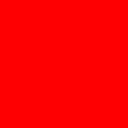

Exists: True Size: 357


In [11]:
# Diagnostic: create and display a simple PNG to test inline image rendering
from PIL import Image
from IPython.display import display, Image as IPImage
import numpy as np
import os
from pathlib import Path
out_path = Path('/tmp/vscode_image_test.png')
arr = np.zeros((128,128,3), dtype=np.uint8)
arr[:] = [255, 0, 0]  # red
img = Image.fromarray(arr)
img.save(out_path)
print('Saved test image to', out_path)
# Try to display inline using IPython.display (this should render in the notebook UI)
display(IPImage(filename=str(out_path)))
# Also check file exists and size for diagnosis
print('Exists:', out_path.exists(), 'Size:', out_path.stat().st_size if out_path.exists() else 'N/A')


In [12]:
# Notebook viewer: display YOLO-format labeled images and segmentation masks inline (with class names from dataset.yaml)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from PIL import Image
import os
from pathlib import Path
import re

DATASET_DIR = Path('/home/salumi/projects/project/yolo_dataset')

# Load class names from dataset.yaml (fallback to simple parser if PyYAML not installed)
CLASS_NAMES = {}
try:
    import yaml
    yaml_path = DATASET_DIR / 'dataset.yaml'
    if yaml_path.exists():
        content = yaml.safe_load(yaml_path.read_text())
        names_map = content.get('names', {}) or {}
        for k, v in names_map.items():
            try:
                CLASS_NAMES[int(k)] = v
            except Exception:
                CLASS_NAMES[len(CLASS_NAMES)] = v
except Exception:
    # fallback simple parser
    yaml_path = DATASET_DIR / 'dataset.yaml'
    if yaml_path.exists():
        txt = yaml_path.read_text()
        m = re.search(r"names:\n((?:\s+\d+:.*\n)+)", txt)
        if m:
            for line in m.group(1).splitlines():
                line = line.strip()
                if ':' in line:
                    k, v = line.split(':', 1)
                    try:
                        CLASS_NAMES[int(k.strip())] = v.strip()
                    except Exception:
                        pass


def _label_name(cls):
    return CLASS_NAMES.get(cls, str(cls))


def load_yolo_labels(label_path, img_w, img_h):
    boxes = []
    segs = []
    if not label_path.exists():
        return boxes, segs
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            vals = list(map(float, parts))
            cls = int(vals[0])
            cx, cy, w, h = vals[1:5]
            x1 = (cx - w/2) * img_w
            y1 = (cy - h/2) * img_h
            boxes.append((cls, x1, y1, w * img_w, h * img_h))

            if len(vals) > 5:
                poly_vals = vals[5:]
                pts = []
                for i in range(0, len(poly_vals), 2):
                    px = poly_vals[i] * img_w
                    py = poly_vals[i+1] * img_h
                    pts.append((px, py))
                if pts:
                    segs.append((cls, pts))
    return boxes, segs


# simple color palette
PALETTE = [(31,119,180),(255,127,14),(44,160,44),(214,39,40),(148,103,189),(140,86,75),(227,119,194),(127,127,127),(188,189,34),(23,190,207)]
PALETTE = [(c[0]/255.0, c[1]/255.0, c[2]/255.0) for c in PALETTE]


def show_yolo_images(dataset_dir=DATASET_DIR, subset='train', n=6, start=0, show_boxes=True):
    img_dir = Path(dataset_dir) / 'images' / subset
    lbl_dir = Path(dataset_dir) / 'labels' / subset
    files = sorted([f for f in os.listdir(img_dir) if not f.startswith('.')])
    sel = files[start:start+n]
    if not sel:
        print('No images to show')
        return

    cols = min(3, len(sel))
    rows = (len(sel) + cols - 1) // cols
    plt.figure(figsize=(5 * cols, 4 * rows))

    for i, fn in enumerate(sel):
        img_path = img_dir / fn
        lbl_path = lbl_dir / (Path(fn).stem + '.txt')
        img = Image.open(img_path).convert('RGB')
        w, h = img.size

        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(img)
        ax.set_title(fn)
        ax.axis('off')

        boxes, segs = load_yolo_labels(lbl_path, w, h)

        # draw segmentation polygons (filled, semi-transparent)
        for idx, (cls, pts) in enumerate(segs):
            color = PALETTE[cls % len(PALETTE)]
            poly = Polygon(pts, closed=True, facecolor=color + (0.35,), edgecolor=color, linewidth=1)
            ax.add_patch(poly)
            # label near first point with class name
            if pts:
                x0, y0 = pts[0]
                ax.text(x0, max(y0-6,0), f"{_label_name(cls)} ({cls})", color='white', fontsize=10, weight='bold', backgroundcolor='black')

        # draw boxes; if a segmentation exists for the same object, compute tight bbox from seg
        if show_boxes:
            if segs:
                for cls, pts in segs:
                    xs = [p[0] for p in pts]
                    ys = [p[1] for p in pts]
                    x_min, x_max = min(xs), max(xs)
                    y_min, y_max = min(ys), max(ys)
                    bw = x_max - x_min
                    bh = y_max - y_min
                    rect = patches.Rectangle((x_min, y_min), bw, bh, linewidth=2, edgecolor='cyan', facecolor='none')
                    ax.add_patch(rect)
                    # also label box with name
                    ax.text(x_min, max(y_min-10,0), f"{_label_name(cls)}", color='cyan', fontsize=9, weight='bold')
            else:
                for cls, x1, y1, bw, bh in boxes:
                    rect = patches.Rectangle((x1, y1), bw, bh, linewidth=2, edgecolor='cyan', facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, max(y1-10,0), f"{_label_name(cls)}", color='cyan', fontsize=9, weight='bold')

    plt.tight_layout()
    plt.show()


# Usage: run this cell then call `show_yolo_images(n=6, start=0)`
print('Viewer cell loaded. Example: show_yolo_images(n=4, start=0)')

Viewer cell loaded. Example: show_yolo_images(n=4, start=0)


In [13]:
show_yolo_images(n=4, start=0)

<Figure size 1500x800 with 4 Axes>